# **🚢 TASK 1: Titanic Survival Classification**

# **1. Import Libraries**
First, let's import the necessary libraries for data manipulation, visualization, and machine learning.bold text

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

## **`2. Load Data`**

Now, let's load the Titanic dataset. Make sure the titanic.csv file is accessible in your Colab environment (e.g., uploaded to the session storage or mounted from Google Drive).

In [57]:
# Load the dataset
try:
    df_titanic = pd.read_csv('/titanic.csv')
    print("Successfully loaded /titanic.csv")
    display(df_titanic.head())
except FileNotFoundError:
    print("Error: 'titanic.csv' not found. Please upload the file or provide the correct path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## **3. Initial Data Exploration**
Let's get a general understanding of the data, including column types, non-null values, and basic statistics, and identify missing values.

In [58]:
print("DataFrame Info:")
df_titanic.info()

print("\nMissing Values:")
print(df_titanic.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Em

## **4. Data Cleaning and Preprocessing**
We will handle missing values and prepare the data for machine learning. This includes filling missing 'Age' and 'Embarked' values and dropping the 'Cabin' column due to a high number of missing entries.

In [59]:
# Fill missing Age with mean
df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True)

# Fill missing Embarked with mode
df_titanic['Embarked'].fillna(df_titanic['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing values), but only if it exists
if 'Cabin' in df_titanic.columns:
    df_titanic.drop('Cabin', axis=1, inplace=True)
else:
    print("Cabin column not found, likely already dropped.")

print("\nMissing Values after cleaning:")
print(df_titanic.isnull().sum())

print("\nFirst 5 rows after cleaning:")
display(df_titanic.head())


Missing Values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

First 5 rows after cleaning:


/tmp/ipykernel_1930/1140635055.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_titanic['Age'].fillna(df_titanic['Age'].mean(), inplace=True)
/tmp/ipykernel_1930/1140635055.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


# **Feature Engineering**
This section shows the process of converting categorical features using one-hot encoding and dropping irrelevant columns.

In [83]:
# Drop irrelevant columns
df_titanic_processed = df_titanic.drop(['Name', 'Ticket', 'PassengerId'], axis=1)

# Convert 'Sex' and 'Embarked' to numerical using one-hot encoding
df_titanic_processed = pd.get_dummies(df_titanic_processed, columns=['Sex', 'Embarked'], drop_first=True)

print("First 5 rows of processed DataFrame:")
display(df_titanic_processed.head())

print("\nProcessed DataFrame Info:")
df_titanic_processed.info()

First 5 rows of processed DataFrame:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True



Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


## **5. Feature Engineering**
We will convert categorical features into a format suitable for machine learning models using one-hot encoding. We'll also drop columns that are not typically useful for prediction like 'Name', 'Ticket', and 'PassengerId'.

In [60]:
# Drop irrelevant columns
df_titanic_processed = df_titanic.drop(['Name', 'Ticket', 'PassengerId'], axis=1)

# Convert 'Sex' and 'Embarked' to numerical using one-hot encoding
df_titanic_processed = pd.get_dummies(df_titanic_processed, columns=['Sex', 'Embarked'], drop_first=True)

print("First 5 rows of processed DataFrame:")
display(df_titanic_processed.head())

print("\nProcessed DataFrame Info:")
df_titanic_processed.info()

First 5 rows of processed DataFrame:


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True



Processed DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


# **6. Data Splitting**
Now, let's separate the features (X) from the target variable (y) and split the data into training and testing sets.

In [61]:
# Define features (X) and target (y)
X = df_titanic_processed.drop('Survived', axis=1)
y = df_titanic_processed['Survived']

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 712 samples
Testing set size: 179 samples



# **7. Model Training**
We will train a Logistic Regression model on our training data.

In [62]:
# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


# **Making Predictions**
This code makes predictions on the test set using the trained Logistic Regression model.

In [64]:
# Make predictions on the test set
y_pred = model.predict(X_test)
print("Predictions generated.")

Predictions generated.


# Classification

This report provides a detailed breakdown of the model's performance metrics like precision, recall, and f1-score.

In [70]:
# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



## **Confusion Matrix**
The confusion matrix shows the number of correct and incorrect predictions made by the classification model compared to the actual outcomes.

In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[90 15]
 [19 55]]


# **8. Model Evaluation**
Finally, let's evaluate the trained model's performance on the test set using a classification report and confusion matrix.

In [72]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Print the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
[[90 15]
 [19 55]]


In [74]:
import matplotlib.pyplot as plt
import seaborn as sns


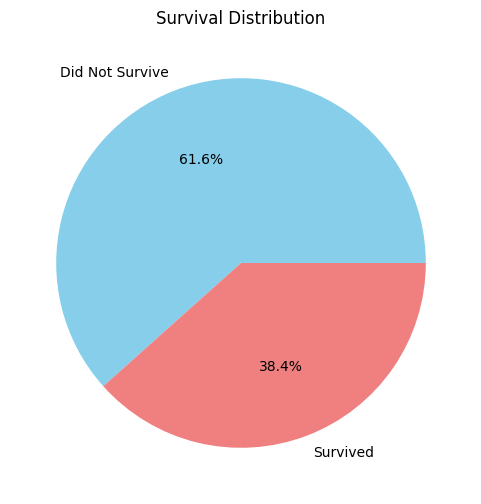

In [76]:
# 1. Pie Chart for Survival Distribution
plt.figure(figsize=(6, 6))
df_titanic['Survived'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], labels=['Did Not Survive', 'Survived'])
plt.title('Survival Distribution')
plt.ylabel('') # Hide the default 'Survived' label
plt.show()

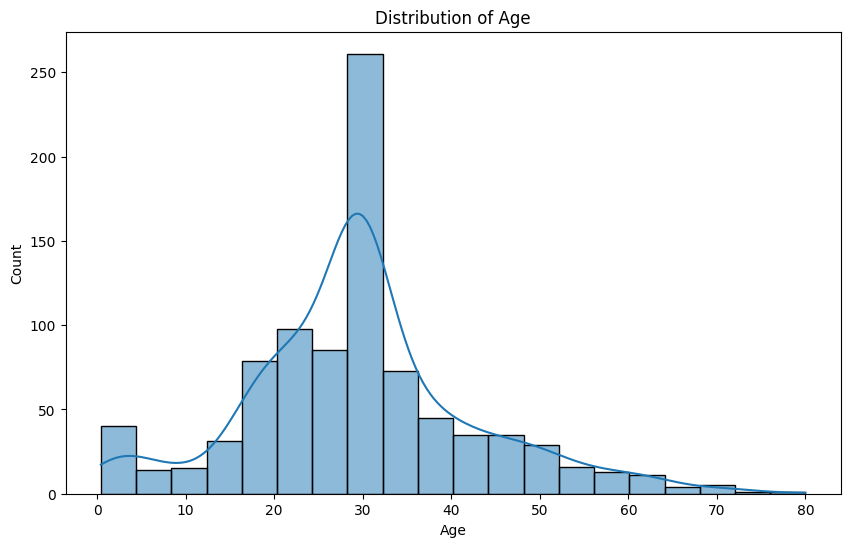

In [77]:

# 2. Histogram for Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_titanic['Age'], bins=20, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_1930/362683292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df_titanic, palette='viridis')


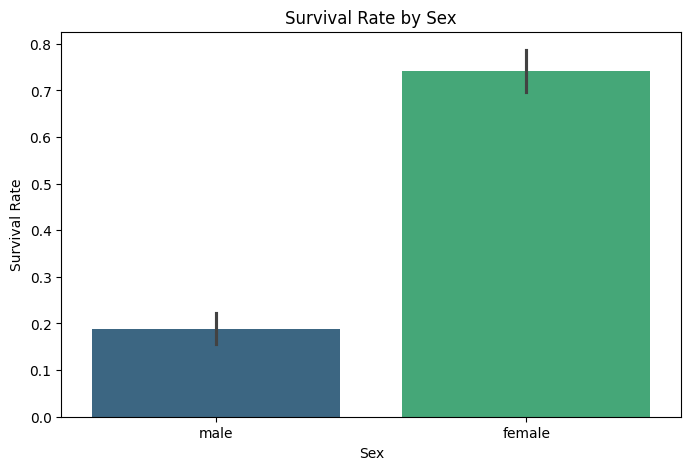

In [78]:

# 3. Bar Chart for Survival by Sex
plt.figure(figsize=(8, 5))
sns.barplot(x='Sex', y='Survived', data=df_titanic, palette='viridis')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()


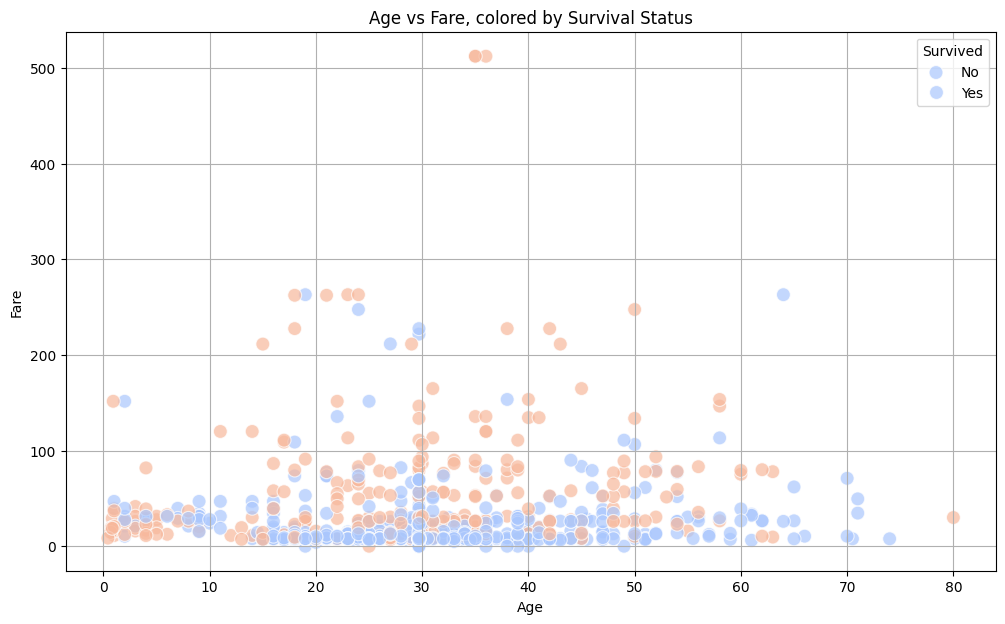

In [79]:
# 5. Scatter Plot for Age vs Fare, colored by Survived
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df_titanic, palette='coolwarm', s=100, alpha=0.7)
plt.title('Age vs Fare, colored by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend(title='Survived', loc='upper right', labels=['No', 'Yes'])
plt.grid(True)
plt.show()

# **9. Further Exploratory Data Analysis: Correlation Heatmap**
Let's visualize the correlations between numerical features to better understand their relationships.

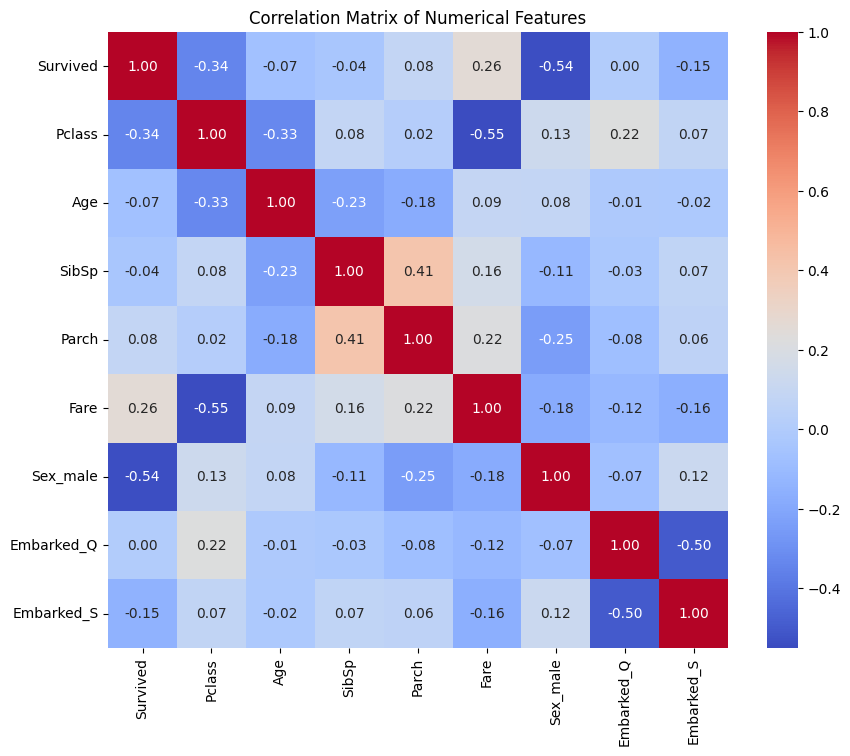

In [82]:
# Calculate the correlation matrix
correlation_matrix = df_titanic_processed.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# **10. Conclusion and Future Work**
Conclusion
In this notebook, we built a Logistic Regression model to predict Titanic survival. We performed data loading, cleaning, preprocessing (handling missing values, encoding categorical features), data splitting, model training, and evaluation. The model achieved an accuracy of approximately 81%, with reasonable precision, recall, and F1-scores for both classes.

The visualizations provided insights into the survival distribution, age distribution, and survival rates by sex and passenger class, and the relationship between age, fare, and survival.

Future Work
To further improve this project, consider the following:

Feature Engineering: Create new features from existing ones (e.g., 'FamilySize' from 'SibSp' and 'Parch', 'Title' from 'Name').
Advanced Models: Experiment with more complex models like Random Forests, Gradient Boosting, or Support Vector Machines.
Hyperparameter Tuning: Optimize the hyperparameters of the chosen model using techniques like GridSearchCV or RandomizedSearchCV.
Cross-Validation: Implement k-fold cross-validation for more robust model evaluation.
Ensemble Methods: Combine multiple models to improve predictive performance.
Outlier Detection: Identify and handle outliers that might be affecting model performance.
More Visualizations: Explore more complex relationships and distributions (e.g., violin plots, pair plots, interaction plots).